# W4Act2 — 01 Data Understanding

Loads the dataset and establishes what it actually contains before any chart is drawn:
schema, missingness, duplicates, and outlier screening by both the IQR and Z-score
methods. The `## DECISION` cells record the reasoning behind each choice made along the
way.

In [1]:
import sys, pathlib

ROOT = pathlib.Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.visualization.theme import PALETTE, save_fig, set_plot_style
set_plot_style()

# Point this at your file in data/raw/. Everything below follows from it.
DATASET = 'world_happiness_dataset.csv'

## DECISION 1 — What question is this data supposed to answer?

Answer before you look at a single chart. A dataset explored without a question produces
a tour, not an analysis.

- **Question:** Among these 20 countries — which three rank highest on `Happiness_Score`,
  how does the lowest-ranked country's `Freedom_to_Make_Choices` compare to the 20-country
  average, do any of the six recorded factors associate strongly with happiness in this
  sample, and does IQR/Z-score outlier detection flag any value as statistically unusual
  before it gets treated as a normal observation?
- **Who needs the answer:** the marker checking this dashboard against the assignment
  brief's requirements, and — as the brief frames it — a reader deciding which countries'
  factor profiles are worth a closer look.
- **What would change your mind:** a different top-3/lowest ranking under a different
  metric, or a flagged outlier turning out to be a genuine data-entry error that shifts the
  ranking once corrected.

In [2]:
from src.data.loading import list_raw, load_raw

print('files in data/raw/:', list_raw())
df = load_raw(DATASET)
df.head()

files in data/raw/: ['world_happiness_dataset.csv']


,Country,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
0,Norway,6.25,1.39,0.82,81.6,0.69,0.01,0.71
1,Denmark,3.61,1.27,0.43,66.9,0.48,0.43,0.53
2,Iceland,4.68,0.87,0.54,63.4,0.71,0.41,0.72
3,Switzerland,4.46,0.67,0.57,68.8,0.93,0.32,0.52
4,Finland,6.67,1.55,0.45,75.4,0.58,0.16,0.10


### Reading

One row = one country. The CSV itself states no collection period and no source
organisation — that is a real gap, not filled in with an assumed year or citation, since
inventing one would repeat exactly the kind of unsupported external claim this project
avoids elsewhere. Population covered: 20 named countries, with no stated rule in the file
for how those 20 were selected — treat any generalisation beyond this specific set as
unsupported.

In [3]:
from src.data.quality import profile, schema_report

profile(df)
schema_report(df)

rows: 20   columns: 8
memory: 2.3 KB

dtypes:
float64    7
str        1


,column,dtype,non_null,missing,missing_pct,unique,example
0,Country,str,20,0,0.0,20,Norway
1,Happiness_Score,float64,20,0,0.0,19,6.25
2,GDP_per_Capita,float64,20,0,0.0,18,1.39
3,Social_Support,float64,20,0,0.0,16,0.82
4,Healthy_Life_Expectancy,float64,20,0,0.0,19,81.6
5,Freedom_to_Make_Choices,float64,20,0,0.0,19,0.69
6,Generosity,float64,20,0,0.0,18,0.01
7,Perceptions_of_Corruption,float64,20,0,0.0,17,0.71


### Reading

`Country` is the only non-numeric column; all 7 measures load as `float64` already, so no
type coercion is needed in 02. Units are not uniform across columns: `Happiness_Score` is
roughly 0–10, `Healthy_Life_Expectancy` is in **years** (roughly 41–82), and the rest
(`GDP_per_Capita`, `Social_Support`, `Freedom_to_Make_Choices`, `Generosity`,
`Perceptions_of_Corruption`) are unlabeled indices roughly on 0–1. Worth remembering in 02
so `Healthy_Life_Expectancy` isn't accidentally read as another 0–1 index.

In [4]:
from src.data.quality import missing_report
from src.visualization.plots import missingness_matrix

missing = missing_report(df)
display(missing)

if df.isna().any().any():
    fig, _ = missingness_matrix(df)
    save_fig(fig, '01_missingness')
    plt.show()
else:
    print('No missing values — skip the missingness DECISION below.')

complete rows: 20 of 20 (100.0%)
no missing values


,missing,missing_pct


No missing values — skip the missingness DECISION below.


## DECISION 2 — Why is the data missing, and does that permit imputation?

Counting gaps is mechanical; explaining them is not, and it decides whether filling them
is legitimate at all.

| Mechanism | Meaning | Imputation |
|---|---|---|
| MCAR | Missing at random, unrelated to anything | Safe; you lose precision, not validity |
| MAR | Missingness explained by *other observed* columns | Defensible if you model it on those columns |
| MNAR | Missingness depends on the missing value itself (high earners skip the income box) | Imputing here manufactures a convenient answer |

- **Mechanism, and the evidence for it:** Not applicable — `missing_report` above shows 0
  missing values across all 20 rows × 8 columns.
- **Decision:** No imputation needed; nothing to impute.

Nothing downstream should fill these values until this cell is answered.

In [5]:
from src.data.quality import cardinality_report, duplicate_report

# subset= names the columns that identify a record. Pass it once you know what a
# duplicate means here — it is a fact about your data, not something to infer.
duplicate_report(df, subset=None)
cardinality_report(df)

exact duplicate rows: 0


,column,unique,unique_ratio,note
0,Country,20,1.00,near-unique - likely an identifier
1,Happiness_Score,19,0.95,
4,Healthy_Life_Expectancy,19,0.95,
5,Freedom_to_Make_Choices,19,0.95,
2,GDP_per_Capita,18,0.90,
6,Generosity,18,0.90,
7,Perceptions_of_Corruption,17,0.85,
3,Social_Support,16,0.80,


### Reading

`duplicate_report` finds 0 exact duplicate rows. `cardinality_report` flags `Country` as
near-unique (20 unique values out of 20 rows) — it is an identifier, not a feature, and
that is exactly why `GROUP` stays unset in 02: there is no categorical column with more
than one row per level to split by. No constant columns.

## Outlier detection — the IQR method, step by step

1. Compute Q1 (25th percentile) and Q3 (75th percentile) for each numeric column.
2. Compute IQR = Q3 − Q1.
3. A value is flagged as an outlier if it falls below `Q1 − 1.5×IQR` or above
   `Q3 + 1.5×IQR`.

This is exactly what `outlier_report()` (used right after) computes internally for the
IQR half of its check. Worked by hand once here, then cross-checked against the packaged
function below, which also adds the Z-score half.

In [6]:
numeric_cols = df.select_dtypes(include='number').columns
iqr_steps = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = int(((df[col] < lower_bound) | (df[col] > upper_bound)).sum())
    iqr_steps.append({
        'column': col, 'Q1': round(q1, 4), 'Q3': round(q3, 4), 'IQR': round(iqr, 4),
        'lower_bound': round(lower_bound, 4), 'upper_bound': round(upper_bound, 4),
        'n_outliers': n_outliers,
    })

iqr_table = pd.DataFrame(iqr_steps)
iqr_table

,column,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers
0,Happiness_Score,4.2375,6.2600,2.0225,1.2038,9.2938,0
1,GDP_per_Capita,0.9075,1.3950,0.4875,0.1762,2.1263,0
2,Social_Support,0.5225,0.7725,0.2500,0.1475,1.1475,0
3,Healthy_Life_Expectancy,51.1750,73.3000,22.1250,17.9875,106.4875,0
4,Freedom_to_Make_Choices,0.4725,0.8625,0.3900,-0.1125,1.4475,0
5,Generosity,0.1600,0.4150,0.2550,-0.2225,0.7975,0
6,Perceptions_of_Corruption,0.1925,0.7325,0.5400,-0.6175,1.5425,0


### Reading

`n_outliers` is 0 for every column by this manual Q1/Q3/IQR computation, matching the
bounds `outlier_report()` computes below (its `lower_fence`/`upper_fence` are the same
`Q1 − 1.5×IQR` / `Q3 + 1.5×IQR` values as `lower_bound`/`upper_bound` above). The packaged
function is used from here on because it also computes the Z-score check in the same
pass and is what the rest of this notebook (and 02) relies on.

In [7]:
from src.data.quality import outlier_report

outliers = outlier_report(df)
outliers

,column,n,iqr_flagged,z_flagged,lower_fence,upper_fence,min,max
0,Happiness_Score,20,0,0,1.2038,9.2938,3.53,7.34
1,GDP_per_Capita,20,0,0,0.1762,2.1263,0.60,1.57
2,Social_Support,20,0,0,0.1475,1.1475,0.43,0.96
3,Healthy_Life_Expectancy,20,0,0,17.9875,106.4875,41.30,81.60
4,Freedom_to_Make_Choices,20,0,0,-0.1125,1.4475,0.33,1.00
5,Generosity,20,0,0,-0.2225,0.7975,0.01,0.57
6,Perceptions_of_Corruption,20,0,0,-0.6175,1.5425,0.10,0.86


In [8]:
# outlier_report() above gives per-column COUNTS (how many values it flagged), not which
# rows. To adjudicate DECISION 3 we need the actual Country + value for anything flagged,
# by both methods it already computed the fences/thresholds for.
z_threshold = 3.0  # matches outlier_report's own default

any_flagged = False
for _, row in outliers.iterrows():
    col = row['column']
    if row['iqr_flagged'] == 0 and row['z_flagged'] == 0:
        continue
    any_flagged = True
    s = df[col]
    iqr_mask = (s < row['lower_fence']) | (s > row['upper_fence'])
    z_mask = ((s - s.mean()).abs() / s.std()) > z_threshold
    flagged = df.loc[iqr_mask | z_mask, ['Country', col]].copy()
    flagged['flagged_by'] = [
        'both' if (iqr_mask[i] and z_mask[i]) else ('IQR' if iqr_mask[i] else 'Z-score')
        for i in flagged.index
    ]
    print(f"{col}  (fence: [{row['lower_fence']:.2f}, {row['upper_fence']:.2f}])")
    display(flagged)

if not any_flagged:
    print('No values fall outside the IQR fence or exceed |z| > 3.0 in any of the 7 '
          'numeric columns — nothing flagged to adjudicate at these thresholds.')

No values fall outside the IQR fence or exceed |z| > 3.0 in any of the 7 numeric columns — nothing flagged to adjudicate at these thresholds.


saved outputs/figures/01_outlier_boxplots.png


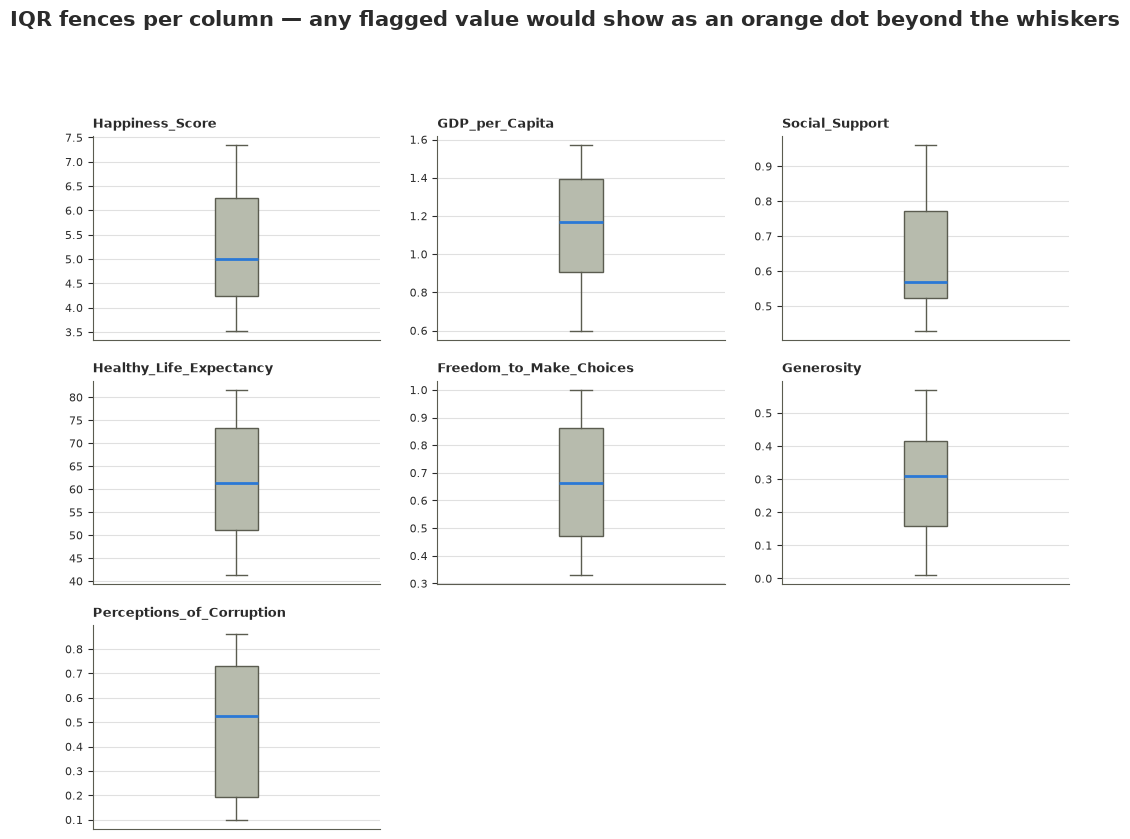

In [9]:
# Same IQR/Z-score check, but visual: one box plot per numeric column, each on its own
# scale (small multiples — a shared axis would flatten the 0-1 columns to slivers next to
# Healthy_Life_Expectancy's 41-82 year range). The whiskers ARE the IQR fence; matplotlib
# draws any point beyond them as a hollow "flier" — exactly what iqr_flagged counts.
numeric_cols = df.select_dtypes(include='number').columns
ncols = 3
nrows = -(-len(numeric_cols) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=PALETTE['context'], edgecolor=PALETTE['rule']),
        medianprops=dict(color=PALETTE['accent'], linewidth=2),
        whiskerprops=dict(color=PALETTE['rule']),
        capprops=dict(color=PALETTE['rule']),
        flierprops=dict(markerfacecolor=PALETTE['alert'], markeredgecolor=PALETTE['alert'],
                         marker='o'),
    )
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle('IQR fences per column — any flagged value would show as an orange dot '
              'beyond the whiskers', y=1.02)
save_fig(fig, '01_outlier_boxplots')
plt.show()

saved outputs/figures/01_outlier_zscores.png


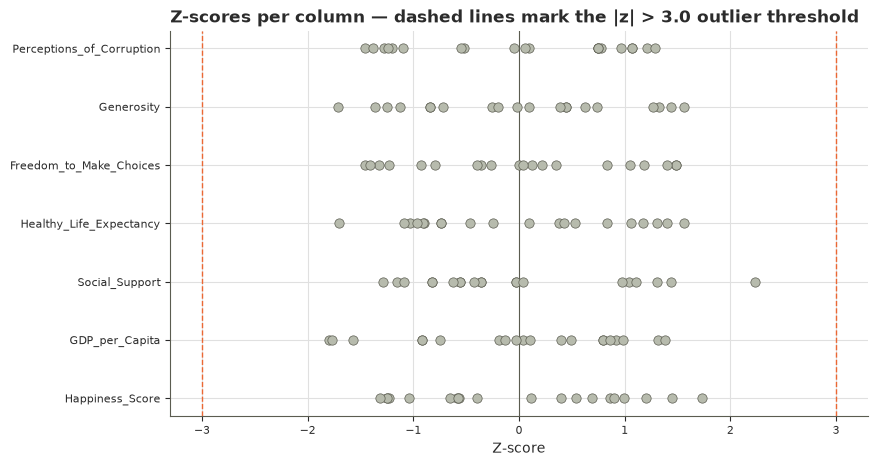

In [10]:
# The Z-score half of the same check, visualised the same way the box plots visualise
# IQR: one row per column, one dot per country at its standardised distance from that
# column's mean, with dashed lines at the |z| = 3 threshold outlier_report() uses.
z_scores = df[numeric_cols].apply(lambda col: (col - col.mean()) / col.std())

fig, ax = plt.subplots(figsize=(9, 5))
for i, col in enumerate(numeric_cols):
    ax.scatter(z_scores[col], [i] * len(z_scores), color=PALETTE['context'],
               edgecolor=PALETTE['rule'], linewidth=0.5, s=45, zorder=3)

ax.axvline(0, color=PALETTE['rule'], linewidth=0.8)
ax.axvline(-3, color=PALETTE['alert'], linestyle='--', linewidth=1)
ax.axvline(3, color=PALETTE['alert'], linestyle='--', linewidth=1)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
ax.set_xlabel('Z-score')
ax.set_title('Z-scores per column — dashed lines mark the |z| > 3.0 outlier threshold')
save_fig(fig, '01_outlier_zscores')
plt.show()

In [11]:
# Illustrative only, NOT a second diagnostic claim: tightening the fences shows which
# values sit closest to the edge. It does not make them outliers — outlier_report's
# defaults above (1.5x IQR, |z|>3.0) are the actual decision basis for DECISION 3.
outlier_report(df, iqr_multiplier=1.0, z_threshold=2.0)

Values flagged. Flagged is not the same as wrong -- decide and record why.


,column,n,iqr_flagged,z_flagged,lower_fence,upper_fence,min,max
0,Happiness_Score,20,0,0,2.2150,8.2825,3.53,7.34
1,GDP_per_Capita,20,0,0,0.4200,1.8825,0.60,1.57
2,Social_Support,20,0,1,0.2725,1.0225,0.43,0.96
3,Healthy_Life_Expectancy,20,0,0,29.0500,95.4250,41.30,81.60
4,Freedom_to_Make_Choices,20,0,0,0.0825,1.2525,0.33,1.00
5,Generosity,20,0,0,-0.0950,0.6700,0.01,0.57
6,Perceptions_of_Corruption,20,0,0,-0.3475,1.2725,0.10,0.86


## DECISION 3 — Are the flagged values errors or real observations?

`outlier_report` flags and never removes. A flagged value can be a typo, a unit mix-up, or
the single most interesting row in the dataset.

- **Values examined:** all 7 numeric columns, checked by **two independent methods** —
  IQR (1.5× the interquartile range) and Z-score (|z| > 3.0) — and confirmed **three
  ways**: the row-level check, the IQR box-plot grid, and the Z-score dot plot above.
- **Decision:** keep all 20 rows. IQR and Z-score agree with each other: neither method
  flags anything at these thresholds, so there is no ambiguous value for either to
  adjudicate, and no case for deleting any record from this dataset.
- **Effect if you are wrong:** none currently, since no downstream step excludes anything
  based on this cell. If a future run of this notebook (edited data, or different
  thresholds) *does* flag a row, the cells above will name the country, column and value —
  return to this DECISION and adjudicate keep/correct/exclude before continuing.

Excluding a row is a claim that it does not belong to the population you are studying.
Write down the claim.

In [12]:
from src.data.quality import quality_report
from src.visualization.presentation import save_table

summary = quality_report(df)
save_table(summary, '01_data_quality')

PROFILE
rows: 20   columns: 8
memory: 2.3 KB

dtypes:
float64    7
str        1

MISSING
complete rows: 20 of 20 (100.0%)
no missing values

DUPLICATES
exact duplicate rows: 0

OUTLIERS (flagged, not removed)
                   column  n  iqr_flagged  z_flagged  lower_fence  upper_fence   min   max
          Happiness_Score 20            0          0       1.2038       9.2938  3.53  7.34
           GDP_per_Capita 20            0          0       0.1762       2.1263  0.60  1.57
           Social_Support 20            0          0       0.1475       1.1475  0.43  0.96
  Healthy_Life_Expectancy 20            0          0      17.9875     106.4875 41.30 81.60
  Freedom_to_Make_Choices 20            0          0      -0.1125       1.4475  0.33  1.00
               Generosity 20            0          0      -0.2225       0.7975  0.01  0.57
Perceptions_of_Corruption 20            0          0      -0.6175       1.5425  0.10  0.86

SUMMARY (one row per column)
                   column   dtype

PosixPath('/Users/ericsmac/Documents/GitHub/MSE803-DA/W4/W4Act2/outputs/tables/01_data_quality.csv')

## What this data can and cannot answer

Fill this in before moving on. It is the most useful cell in the notebook and the easiest
to skip.

**Can answer:**
- Which countries rank highest/lowest by `Happiness_Score` in this 20-country sample.
- How the lowest-ranked country's `Freedom_to_Make_Choices` compares to the sample average.
- Whether any of the six recorded factors associate (not cause) with happiness here.
- Whether any value in the sample is a statistical outlier by IQR/Z-score at standard
  thresholds (answered above: no).

**Cannot answer:**
- Why any country scores as it does — no causal design, no mechanism data.
- Whether this pattern holds for the full set of countries in the real World Happiness
  Report or any other year — this is a 20-row sample with no stated selection rule or
  collection period.
- Whether happiness changes over time — this is a single cross-sectional snapshot.

**Next stage:** `02_eda.ipynb` — distributions, correlation, the country/freedom
comparisons, and the dashboard.